# Search: Solving a Maze Using a Goal-based Agent


## Learning Outcomes

* Formulate search problems using key components like initial state, actions, and goal state in a deterministic, fully observable environment.
* Implement and compare search algorithms including BFS, DFS, GBFS, A*, and IDS for planning paths through mazes.
* Analyze algorithm performance by measuring path cost, node expansions, depth, and memory usage across various maze types.
* Use visualization tools to represent maze paths and support debugging and analysis.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file. 


## Introduction

In this exercise, we will implement the planning function for a type of goal-based agent called a __planning agent__. The planning function uses a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. We will only focus on the planning function, so you do not need to implement an environment, just use the map to search for a path to solve the maze. 

Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the plan step-by-step and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent 
that ignores all percepts and just follows the plan. I will show you a short example, but you do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.** 
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state. 
* **Discrete** means that we have a **finite set of states.** The maze has a finite set 
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The 
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible. 

Several mazes for this exercise are stored as text files. We need to make sure that they are locally available.

In [1]:
# change directory to Google Drive for Google Colab
try:
    from google.colab import drive
    import os

    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Colab Notebooks/')
    print("Your working directory is now Google Drive: My Drive > Colab Notebooks")
except ImportError:
    pass

In [2]:
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

base_url = "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Search/"
download("maze_helper.py", base_url)

mazes = ["small_maze.txt", "medium_maze.txt", "large_maze.txt", "L_maze.txt", "empty_maze.txt", "empty_maze_2.txt", "loops_maze.txt", "open_maze.txt", ]
for maze in mazes:
    download(maze, base_url)

Here is the small example maze:

In [3]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`. 

In [4]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

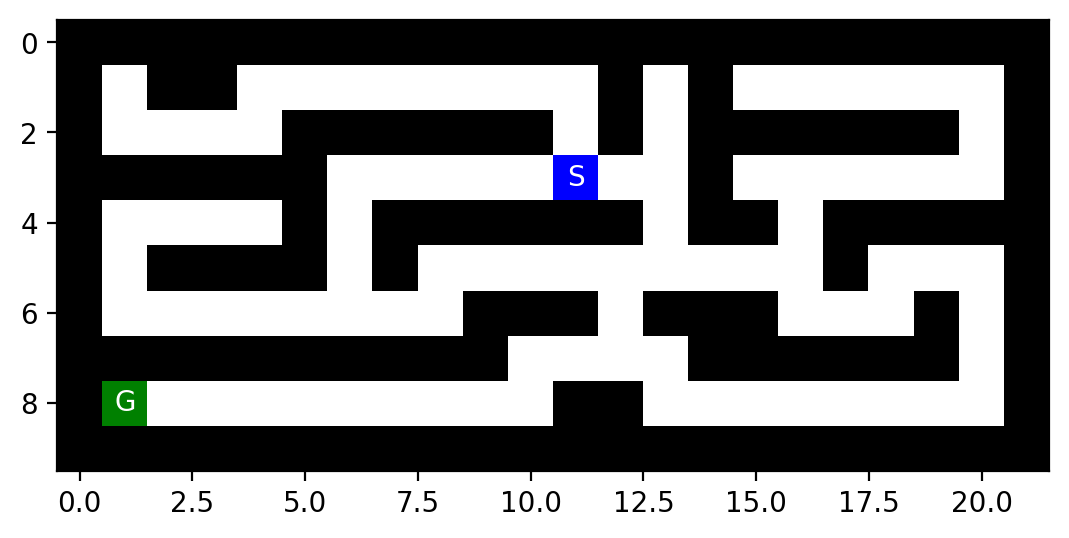

In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [6]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (np.int64(3), np.int64(11))
Goal location: (np.int64(8), np.int64(1))


Helper function documentation.

In [7]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment by Michael Hahsler
    Usage:
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        (Experimental) Build an animation from a list of mazes.

        Parameters:
            result: a list with the elements path, reached, actions and maze_anim with a list of maze arrays that contain what you want to visualize.
            repeat: if True, the animation will repeat.

    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one.
        Caution: there is no error checking!

        Parameters:
            maze: a array with characters produced by parse_maze()
            what: the letter to be found ('S' for start and 'G' for goal)

        Returns:
            a tupple (x, y) for the found position.

    look(maze, pos)
        Look at the label of a square with the position as an array of the form (x

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## An Example for a Planning Agent

I will show you here how to implement a simple agent that uses a random plan. It will not solve the maze, but show you how the mechanics work.

First, we define a generic planning agent that fist plans, and then executes the plan step-by-step. 

In [8]:
class Planning_Agent:
    def __init__(self, maze, start, goal, planning_function):
        self.maze = maze
        self.start = start
        self.goal = goal
        self.planning_function = planning_function
        self.plan = None
        self.progress = None

    def act(self):
        # plan if no plan exists
        if self.plan is None:
            print("Planning...")
            self.plan = self.planning_function(self.maze, self.start, self.goal)
            self.progress = 0
        
        # check if plan is completed
        if self.progress >= len(self.plan):        
            raise Exception("Completed Plan. No more planned actions")
        
        # follow the plan
        action = self.plan[self.progress]
        print(f"Following plan... step {self.progress}: {action}")

        self.progress += 1
        return action

Next, we define the planning function. This function is what you will implement in this assignment.  

In [9]:
import numpy as np

def plan_random(maze, start, goal):
    """Create a random plan with 10 steps"""
    plan = np.random.choice(["N", "E", "S", "W"], size=10, replace=True).tolist()
    return plan

plan_random(maze, (1,1), (8,8))

['N', 'E', 'S', 'S', 'N', 'E', 'N', 'W', 'S', 'N']

This planning function is not great and will not produce a plan that solves the maze. Your planning functions will do better.

Finally, we can create the planning agent, give it the planning function and implement a simple environment that asks it 11 times for an action.

In [10]:
my_agent = Planning_Agent(maze, mh.find_pos(maze, what = "S"), mh.find_pos(maze, what = "G"), plan_random)

def environment(agent_function, steps):
    for _ in range(steps):
        try:
            agent_function()
        except Exception as e:
            print(f"Agent exception: {e}")

environment(my_agent.act, steps=11)

Planning...
Following plan... step 0: W
Following plan... step 1: E
Following plan... step 2: E
Following plan... step 3: N
Following plan... step 4: N
Following plan... step 5: E
Following plan... step 6: S
Following plan... step 7: E
Following plan... step 8: W
Following plan... step 9: W
Agent exception: Completed Plan. No more planned actions


Note: The agent and environment implementation above is just an illustration. You will only implement and experiment with different versions of the planning function.

## Tree structure

To use tree search, you will need to implement a tree data structure in Python. 
Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [11]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"
    
    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
    
        while not node.parent is None:
            node = node.parent
            path.append(node)
        
        path.reverse()
        
        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithms for solving different mazes:

    - Breadth-first search (BFS)
    - Depth-first search (DFS)
    - Greedy best-first search (GBFS)
    - A* search

2. Run each of the above algorithms on the 
    - [small maze](small_maze.txt), 
    - [medium maze](medium_maze.txt), 
    - [large maze](large_maze.txt), 
    - [open maze](open_maze.txt),
    - [L maze](L_maze.txt),
    - [loops maze](loops_maze.txt),
    - [empty maze](empty_maze.txt), and
    - [empty maze (rotated)](empty_maze_2.txt).
    
3. For each problem instance and each search algorithm, report the following in a table:

    - The solution and its path cost
    - Total number of nodes expanded
    - Maximum tree depth
    - Maximum size of the frontier

4. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [10 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate. 

*Note:* You can switch the next block from code to Markdown and use formatting.

### Answer

- **Initial state:** vị trí của S trong mê cung, được biểu diễn bằng một tuple (row, col).
- **Actions:** tác tử có thể di chuyển một ô theo bốn hướng N, E, S, W, với điều kiện ô đích không phải là tường X và vẫn nằm trong giới hạn của mê cung.
- **Transition model:** khi thực hiện một hành động, vị trí hiện tại của tác tử sẽ thay đổi sang ô liền kề theo hướng tương ứng. Ví dụ, hành động N sẽ chuyển trạng thái từ (r, c) sang (r-1, c).
- **Goal state:** vị trí của G trong mê cung.
- **Goal test:** trạng thái hiện tại bằng vị trí của goal, tức là state == goal.
- **Path cost:** mỗi hành động di chuyển hợp lệ có chi phí bằng 1, vì vậy tổng chi phí của đường đi chính là số hành động cần thực hiện để đi từ S đến G.

Thông tin phục vụ quá trình tìm kiếm không được lưu trực tiếp lên bản đồ mê cung mà được quản lý thông qua cây tìm kiếm, frontier và cấu trúc reached, đúng theo yêu cầu của bài.


Give some estimates for the problem size:

* $n$: là tổng số ô có thể đi được trong mê cung, bao gồm S, G và các ô trống. Có thể xác định bằng cách đếm tất cả các ô không phải là tường.
* $d$: vì mỗi hành động đều có chi phí bằng 1 nên \(d\) chính là độ dài của đường đi ngắn nhất từ S đến G. Có thể sử dụng BFS để xác định chính xác giá trị này.
* $m$: nếu không kiểm tra chu trình thì cây tìm kiếm có thể phát triển vô hạn do tác tử có thể quay lại các trạng thái cũ. Khi có kiểm tra chu trình trên đường đi hiện tại, mỗi trạng thái không xuất hiện hai lần trên cùng một đường đi nên \(m\) tối đa xấp xỉ số trạng thái có thể đi được trừ 1.
* $b$: tối đa bằng 4 vì từ một ô tác tử có thể đi theo bốn hướng Bắc, Đông, Nam và Tây. Tuy nhiên, trong thực tế tường và biên của mê cung sẽ làm giảm số hành động hợp lệ.

### Problem-size estimates

- **State-space size `n`:** the number of traversable cells in the maze (`S`, `G`, and blank cells). It can be calculated by counting all cells that are not walls.
- **Optimal-solution depth `d`:** because each move costs 1, `d` equals the length of the shortest path from `S` to `G`. BFS can be used to determine it exactly.
- **Maximum tree depth `m`:** without cycle checking, the search tree can be unbounded because the agent can revisit states. With path-cycle checking, a path cannot contain the same state twice, so `m` is at most the number of traversable states minus 1.
- **Maximum branching factor `b`:** at most 4 because the agent can move north, east, south, or west. Walls and boundaries usually reduce the effective branching factor.


## Task 2: Uninformed search: Breadth-first and depth-first [40 Points]

Implement these search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important notes** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.
* DSF behavior can be implemented using the BFS tree search algorithm and simply changing the order in which the frontier is expanded (this is equivalent to best-first search with path length as the criterion to expand the next node). However, this would be a big mistake since it combines the bad space complexity of BFS with the bad time complexity of DFS! **To take advantage of the significantly smaller memory footprint of DFS, you need to implement DFS in a different way without a `reached` data structure (often also called `visited` or `explored`) and by releasing the memory for nodes that are not needed anymore.**
* Since the proper implementation of DFS does not use a `reached` data structure, redundant path checking abilities are limited to cycle checking. 
You need to implement **cycle checking since DSF is incomplete (produces an infinite loop) if cycles cannot be prevented.** You will see in your experiments that cycle checking in open spaces is challenging.

In [12]:
from collections import deque
import heapq
import itertools
import math
import time

# Fixed order makes the experiments reproducible.
ACTION_DELTAS = {
    "N": (-1, 0),
    "E": (0, 1),
    "S": (1, 0),
    "W": (0, -1),
}
ACTION_ORDER = ["N", "E", "S", "W"]


def valid_successors(maze, pos):
    """Return (action, next_position) pairs for legal 4-neighbour moves."""
    rows, cols = maze.shape
    r, c = pos
    children = []
    for action in ACTION_ORDER:
        dr, dc = ACTION_DELTAS[action]
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols and maze[nr, nc] != "X":
            children.append((action, (nr, nc)))
    return children


def node_actions(node):
    """Return the action sequence from the root to node."""
    if node is None:
        return None
    return [n.action for n in node.get_path_from_root()[1:]]


def path_positions(node):
    if node is None:
        return []
    return [n.pos for n in node.get_path_from_root()]


def _result(node, expanded, max_depth, max_frontier, max_memory, runtime, status="success"):
    plan = node_actions(node)
    return {
        "node": node,
        "plan": plan,
        "path": path_positions(node),
        "path_cost": None if node is None else node.cost,
        "expanded": expanded,
        "max_depth": max_depth,
        "max_frontier": max_frontier,
        "max_memory": max_memory,
        "runtime": runtime,
        "status": status,
    }


def bfs(maze, start, goal):
    """Breadth-first graph search using a FIFO queue and a reached set."""
    t0 = time.perf_counter()
    root = Node(start, None, None, 0)
    if tuple(start) == tuple(goal):
        return _result(root, 0, 0, 1, 2, time.perf_counter() - t0)

    frontier = deque([root])
    reached = {root.pos}
    expanded = 0
    max_depth = 0
    max_frontier = 1
    max_memory = len(frontier) + len(reached)

    while frontier:
        node = frontier.popleft()
        expanded += 1
        max_depth = max(max_depth, node.cost)

        for action, child_pos in valid_successors(maze, node.pos):
            if child_pos in reached:
                continue
            child = Node(child_pos, node, action, node.cost + 1)
            if child_pos == tuple(goal):
                max_depth = max(max_depth, child.cost)
                runtime = time.perf_counter() - t0
                return _result(child, expanded, max_depth,
                               max(max_frontier, len(frontier) + 1),
                               max(max_memory, len(frontier) + len(reached) + 2),
                               runtime)
            reached.add(child_pos)
            frontier.append(child)

        max_frontier = max(max_frontier, len(frontier))
        max_memory = max(max_memory, len(frontier) + len(reached))

    return _result(None, expanded, max_depth, max_frontier, max_memory,
                   time.perf_counter() - t0, status="failure")


def _in_current_path(node, pos):
    """Cycle check used by DFS without a global reached set."""
    while node is not None:
        if node.pos == pos:
            return True
        node = node.parent
    return False


def dfs(maze, start, goal, max_expansions=200000):
    """Depth-first tree search with path-cycle checking and no global reached set."""
    t0 = time.perf_counter()
    root = Node(start, None, None, 0)
    frontier = [root]
    expanded = 0
    max_depth = 0
    max_frontier = 1
    max_memory = 1

    while frontier:
        node = frontier.pop()
        if node.pos == tuple(goal):
            return _result(node, expanded, max_depth, max_frontier, max_memory,
                           time.perf_counter() - t0)

        expanded += 1
        if expanded >= max_expansions:
            return _result(None, expanded, max_depth, max_frontier, max_memory,
                           time.perf_counter() - t0, status="expansion limit reached")

        max_depth = max(max_depth, node.cost)
        successors = valid_successors(maze, node.pos)

        # Reverse insertion so N is considered first when popping from the stack.
        for action, child_pos in reversed(successors):
            if _in_current_path(node, child_pos):
                continue
            child = Node(child_pos, node, action, node.cost + 1)
            frontier.append(child)
            max_depth = max(max_depth, child.cost)

        max_frontier = max(max_frontier, len(frontier))
        # DFS stores the frontier plus the current path, not a global reached set.
        max_memory = max(max_memory, len(frontier) + node.cost + 1)

    return _result(None, expanded, max_depth, max_frontier, max_memory,
                   time.perf_counter() - t0, status="failure")


How does BFS and DFS (without a reached data structure) deal with loops (cycles)?

### Discussion: cycles in BFS and DFS

Trong cài đặt này, BFS sử dụng tập reached. Mỗi trạng thái sẽ được thêm vào reached ngay khi nó được sinh ra lần đầu tiên, vì vậy cùng một vị trí trong mê cung sẽ không bị thêm lại vào frontier nhiều lần. Cách này giúp ngăn chu trình và tránh việc mở rộng lặp lại các trạng thái đã được khám phá.

Ngược lại, DFS không sử dụng một tập reached toàn cục nhằm giữ ưu điểm sử dụng ít bộ nhớ. Thay vào đó, trước khi thêm một node con vào frontier, thuật toán kiểm tra xem trạng thái đó đã xuất hiện trên đường đi hiện tại từ node gốc đến node đang xét hay chưa. Cách này ngăn DFS tạo ra chu trình ngay trên cùng một nhánh. Tuy nhiên, cùng một trạng thái vẫn có thể được đi tới thông qua các nhánh khác nhau, vì vậy DFS vẫn có thể lặp lại công việc và gặp vấn đề trong những vùng mở có nhiều đường đi thay thế.


Are your implementations complete and optimal? Explain why. What is the time and space complexity of each of **your** implementations? Especially discuss the difference in space complexity between BFS and DFS.

### Discussion: completeness, optimality, time, and space

**BFS.** BFS là complete trong mê cung hữu hạn vì nếu tồn tại đường đi đến goal thì thuật toán cuối cùng sẽ duyệt đến trạng thái đó. Việc sử dụng reached cũng ngăn các trạng thái bị mở rộng vô hạn do chu trình.
BFS cũng optimal trong bài toán này vì mọi hành động đều có cùng chi phí bằng 1. BFS mở rộng các node theo độ sâu tăng dần nên goal đầu tiên được tìm thấy sẽ nằm trên một đường đi có số bước nhỏ nhất.
Độ phức tạp thời gian trong trường hợp xấu nhất có thể biểu diễn là:$O(b^d)$
và độ phức tạp bộ nhớ cũng khoảng: $O(b^d)$
Nhược điểm lớn nhất của BFS là cần lưu toàn bộ frontier và tập reached, vì vậy lượng bộ nhớ có thể tăng rất nhanh.

**DFS.** DFS với kiểm tra chu trình trên đường đi hiện tại sẽ tránh được việc một nhánh quay lại chính các node tổ tiên của nó. Trong một mê cung hữu hạn, điều này giúp mỗi nhánh có độ dài hữu hạn.
Tuy nhiên, DFS không đảm bảo optimal, vì thuật toán có thể đi sâu vào một nhánh rất dài và tìm thấy goal trước khi khám phá một đường đi ngắn hơn.
Độ phức tạp thời gian trong trường hợp xấu nhất là: $O(b^m)$
trong đó $m$ là độ sâu tối đa.
Ưu điểm chính của DFS là sử dụng ít bộ nhớ hơn BFS. Trong dạng DFS chuẩn, bộ nhớ thường vào khoảng: $O(bm)$
vì thuật toán chủ yếu lưu đường đi hiện tại và một số node anh em chưa được mở rộng.


## Task 3: Informed search: Implement greedy best-first search and A* search  [20 Points]

You can use the map to estimate the distance from your current position to the goal using the Manhattan distance (see https://en.wikipedia.org/wiki/Taxicab_geometry) as a heuristic function. Both algorithms are based on Best-First search which requires only a small change from the BFS algorithm you have already implemented (see textbook/slides). 

In [13]:
def manhattan(pos, goal):
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])


def best_first_search(maze, start, goal, mode="greedy"):
    """Shared implementation for GBFS and A* graph search."""
    if mode not in {"greedy", "astar"}:
        raise ValueError("mode must be 'greedy' or 'astar'")

    t0 = time.perf_counter()
    root = Node(start, None, None, 0)
    counter = itertools.count()

    def priority(node):
        h = manhattan(node.pos, goal)
        return h if mode == "greedy" else node.cost + h

    frontier = [(priority(root), next(counter), root)]
    best_g = {root.pos: 0}
    expanded = 0
    max_depth = 0
    max_frontier = 1
    max_memory = len(frontier) + len(best_g)

    while frontier:
        _, _, node = heapq.heappop(frontier)

        # Skip stale entries when a better path to this state was found later.
        if node.cost != best_g.get(node.pos):
            continue

        if node.pos == tuple(goal):
            return _result(node, expanded, max_depth, max_frontier, max_memory,
                           time.perf_counter() - t0)

        expanded += 1
        max_depth = max(max_depth, node.cost)

        for action, child_pos in valid_successors(maze, node.pos):
            new_g = node.cost + 1
            if new_g < best_g.get(child_pos, math.inf):
                best_g[child_pos] = new_g
                child = Node(child_pos, node, action, new_g)
                heapq.heappush(frontier, (priority(child), next(counter), child))
                max_depth = max(max_depth, child.cost)

        max_frontier = max(max_frontier, len(frontier))
        max_memory = max(max_memory, len(frontier) + len(best_g))

    return _result(None, expanded, max_depth, max_frontier, max_memory,
                   time.perf_counter() - t0, status="failure")


def gbfs(maze, start, goal):
    return best_first_search(maze, start, goal, mode="greedy")


def astar(maze, start, goal):
    return best_first_search(maze, start, goal, mode="astar")


# Quick test on the currently loaded maze
start = mh.find_pos(maze, what="S")
goal = mh.find_pos(maze, what="G")
for name, algorithm in [("BFS", bfs), ("DFS", dfs), ("GBFS", gbfs), ("A*", astar)]:
    result = algorithm(maze, start, goal)
    print(name, "status=", result["status"],
          "cost=", result["path_cost"],
          "expanded=", result["expanded"],
          "max frontier=", result["max_frontier"])


BFS status= success cost= 19 expanded= 90 max frontier= 9
DFS status= success cost= 37 expanded= 93 max frontier= 5
GBFS status= success cost= 29 expanded= 39 max frontier= 5
A* status= success cost= 19 expanded= 53 max frontier= 8


Are your implementations complete and optimal? What is the time and space complexity?

### Discussion: GBFS and A*

**GBFS** Thuật toán chỉ quan tâm đến khoảng cách ước lượng từ node hiện tại đến goal mà không xét chi phí đã đi \(g(n)\).
Do đó, GBFS thường hướng rất nhanh về phía goal và trong nhiều trường hợp có thể mở rộng ít node hơn BFS. Tuy nhiên, vì không xét chi phí đã đi nên GBFS không đảm bảo tìm được đường đi tối ưu.
Trong một mê cung hữu hạn, nếu implementation sử dụng cơ chế kiểm tra trạng thái phù hợp thì GBFS có thể tìm được goal nếu goal có thể đạt tới.

**A\*** Với mê cung chỉ cho phép di chuyển theo bốn hướng và mỗi bước có chi phí bằng 1, Manhattan distance là một heuristic admissible và consistent.
Vì vậy A* trong trường hợp này là complete và optimal.
Trong trường hợp xấu nhất, A* vẫn có thể cần thời gian và bộ nhớ rất lớn, nhưng nếu heuristic tốt thì số trạng thái cần mở rộng thường ít hơn đáng kể so với BFS. PDF cũng yêu cầu so sánh trực tiếp BFS với A* dựa trên hiệu quả heuristic.


## Task 4: Comparison and discussion [20 Points] 

Run experiments to compare the implemented algorithms.

How to deal with issues:

* Your implementation returns unexpected results: Try to debug and fix the code. Visualizing the maze, the current path and the frontier after every step is very helpful. If the code still does not work, then mark the result with an asterisk (*) and describe the issue below the table.

* Your implementation cannot consistently solve a specific maze and ends up in an infinite loop:
    Debug (likely your frontier and cycle checking for DFS are the issue). If it is a shortcoming of the algorithm/implementation, then put "N/A*" in the results table and describe why this is happening.

In [14]:
import pandas as pd


def load_maze_file(filename):
    with open(filename, "r") as f:
        maze_text = f.read()
    return mh.parse_maze(maze_text)


def run_experiment(filename, algorithm_name, algorithm):
    m = load_maze_file(filename)
    start = mh.find_pos(m, what="S")
    goal = mh.find_pos(m, what="G")
    result = algorithm(m, start, goal)
    return {
        "maze": filename.replace("_maze.txt", ""),
        "algorithm": algorithm_name,
        "path cost": result["path_cost"],
        "nodes expanded": result["expanded"],
        "max tree depth": result["max_depth"],
        "max nodes in memory": result["max_memory"],
        "max frontier": result["max_frontier"],
        "time (s)": result["runtime"],
        "status": result["status"],
    }

algorithms = {
    "BFS": bfs,
    "DFS": dfs,
    "GBFS": gbfs,
    "A*": astar,
}

# The PDF asks for at least three mazes. Add/remove maze names here if desired.
experiment_mazes = ["small_maze.txt", "medium_maze.txt", "large_maze.txt"]
rows = []
for maze_file in experiment_mazes:
    for algorithm_name, algorithm in algorithms.items():
        row = run_experiment(maze_file, algorithm_name, algorithm)
        rows.append(row)
        print(row)

results_df = pd.DataFrame(rows)
results_df


{'maze': 'small', 'algorithm': 'BFS', 'path cost': 19, 'nodes expanded': 90, 'max tree depth': 19, 'max nodes in memory': 96, 'max frontier': 9, 'time (s)': 0.000519299996085465, 'status': 'success'}
{'maze': 'small', 'algorithm': 'DFS', 'path cost': 37, 'nodes expanded': 93, 'max tree depth': 44, 'max nodes in memory': 48, 'max frontier': 5, 'time (s)': 0.0007091000443324447, 'status': 'success'}
{'maze': 'small', 'algorithm': 'GBFS', 'path cost': 29, 'nodes expanded': 39, 'max tree depth': 29, 'max nodes in memory': 49, 'max frontier': 5, 'time (s)': 0.0002984000602737069, 'status': 'success'}
{'maze': 'small', 'algorithm': 'A*', 'path cost': 19, 'nodes expanded': 53, 'max tree depth': 19, 'max nodes in memory': 66, 'max frontier': 8, 'time (s)': 0.0003787999739870429, 'status': 'success'}
{'maze': 'medium', 'algorithm': 'BFS', 'path cost': 68, 'nodes expanded': 267, 'max tree depth': 68, 'max nodes in memory': 273, 'max frontier': 9, 'time (s)': 0.0016575000481680036, 'status': 'suc

,maze,algorithm,path cost,nodes expanded,max tree depth,max nodes in memory,max frontier,time (s),status
0,small,BFS,19,90,19,96,9,0.000519,success
1,small,DFS,37,93,44,48,5,0.000709,success
2,small,GBFS,29,39,29,49,5,0.000298,success
3,small,A*,19,53,19,66,8,0.000379,success
4,medium,BFS,68,267,68,273,9,0.001658,success
5,medium,DFS,244,267,244,257,14,0.005322,success
6,medium,GBFS,74,78,74,86,4,0.000936,success
7,medium,A*,68,221,68,235,8,0.002700,success
8,large,BFS,210,618,210,626,8,0.005273,success
9,large,DFS,210,519,222,255,34,0.009873,success


Complete the following table for each maze.

__Small maze__

| algorithm | path cost | # of nodes expanded | max tree depth | max # of nodes in memory | max frontier size |
|-----------|-----------|----------------|----------------|---------------|-------------------|
| BFS       |         19|              90|              19|             96|                  9|
| DFS       |         37|              93|              44|             48|                  5|
| GBS       |         29|              39|              29|             49|                  5|
| A*        |         19|              53|              19|             66|                  8|

__Medium Maze__

| algorithm | path cost | # of nodes expanded | max tree depth | max # of nodes in memory | max frontier size |
|-----------|-----------|----------------|----------------|---------------|-------------------|
| BFS       |         68|             267|              68|            273|                  9|
| DFS       |        244|             267|             244|            257|                 14|
| GBS       |         74|              78|              74|             86|                  4|
| A*        |         68|             221|              68|            235|                  8|

__Large Maze__

| algorithm | path cost | # of nodes expanded | max tree depth | max # of nodes in memory | max frontier size |
|-----------|-----------|----------------|----------------|---------------|-------------------|
| BFS       |        210|             618|             210|            626|                  8|
| DFS       |        210|             519|             222|            255|                 34|
| GBS       |        210|             466|             210|            508|                 21|
| A*        |        210|             549|             210|            565|                 12|


Present the results as using charts (see [Python Code Examples/charts and tables](../HOWTOs/charts_and_tables.ipynb)). 

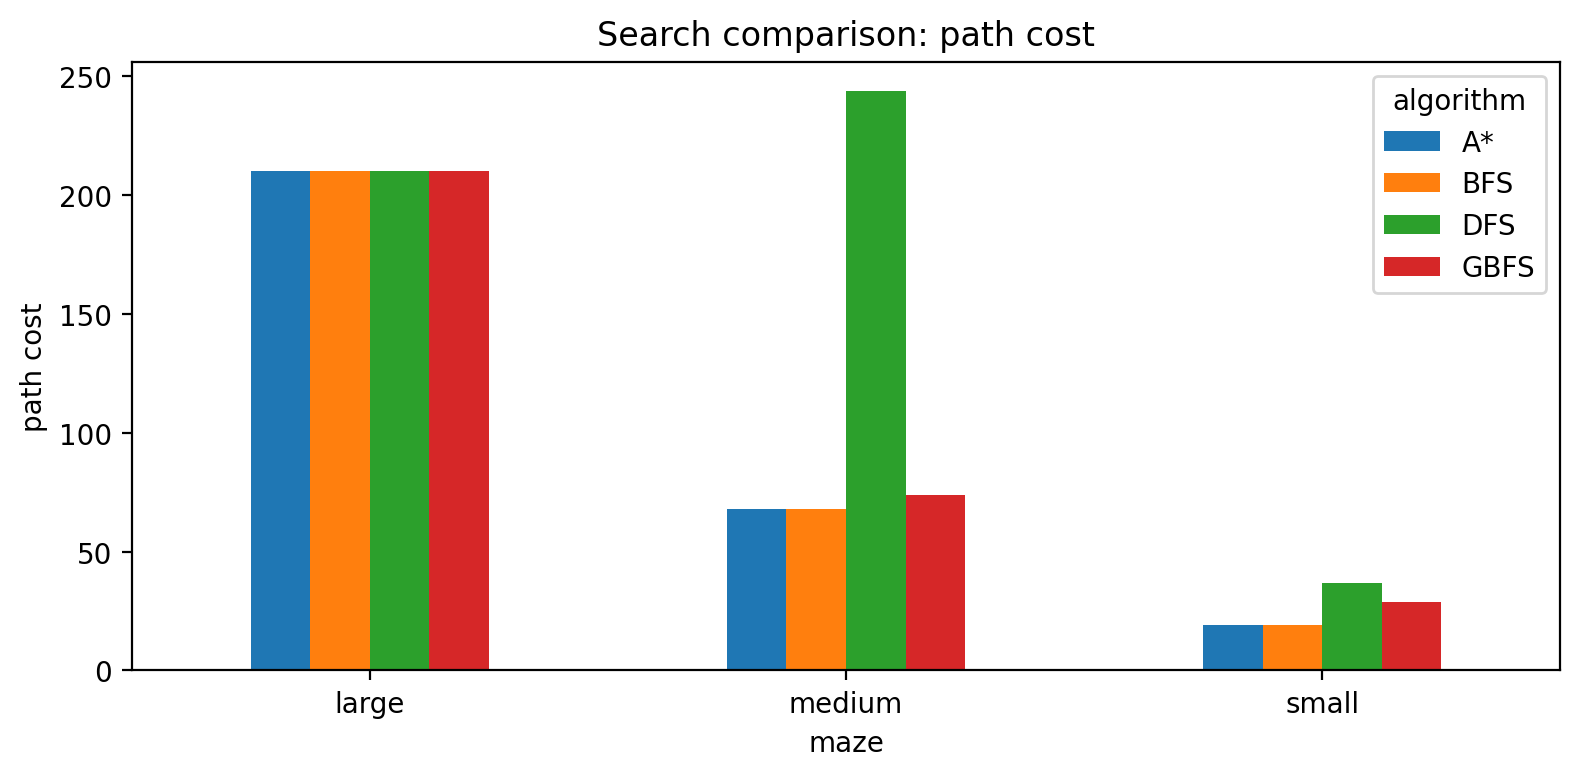

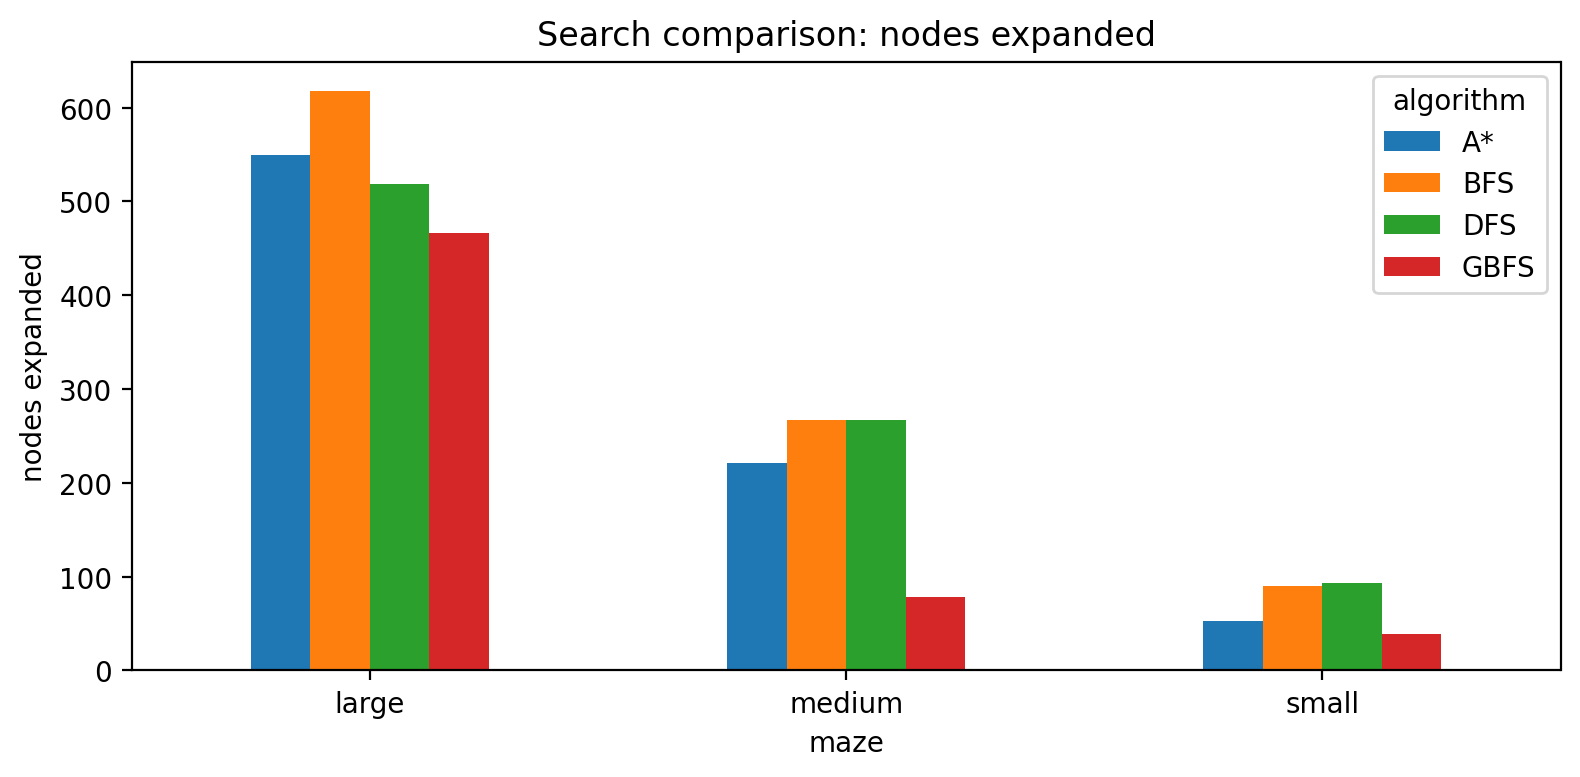

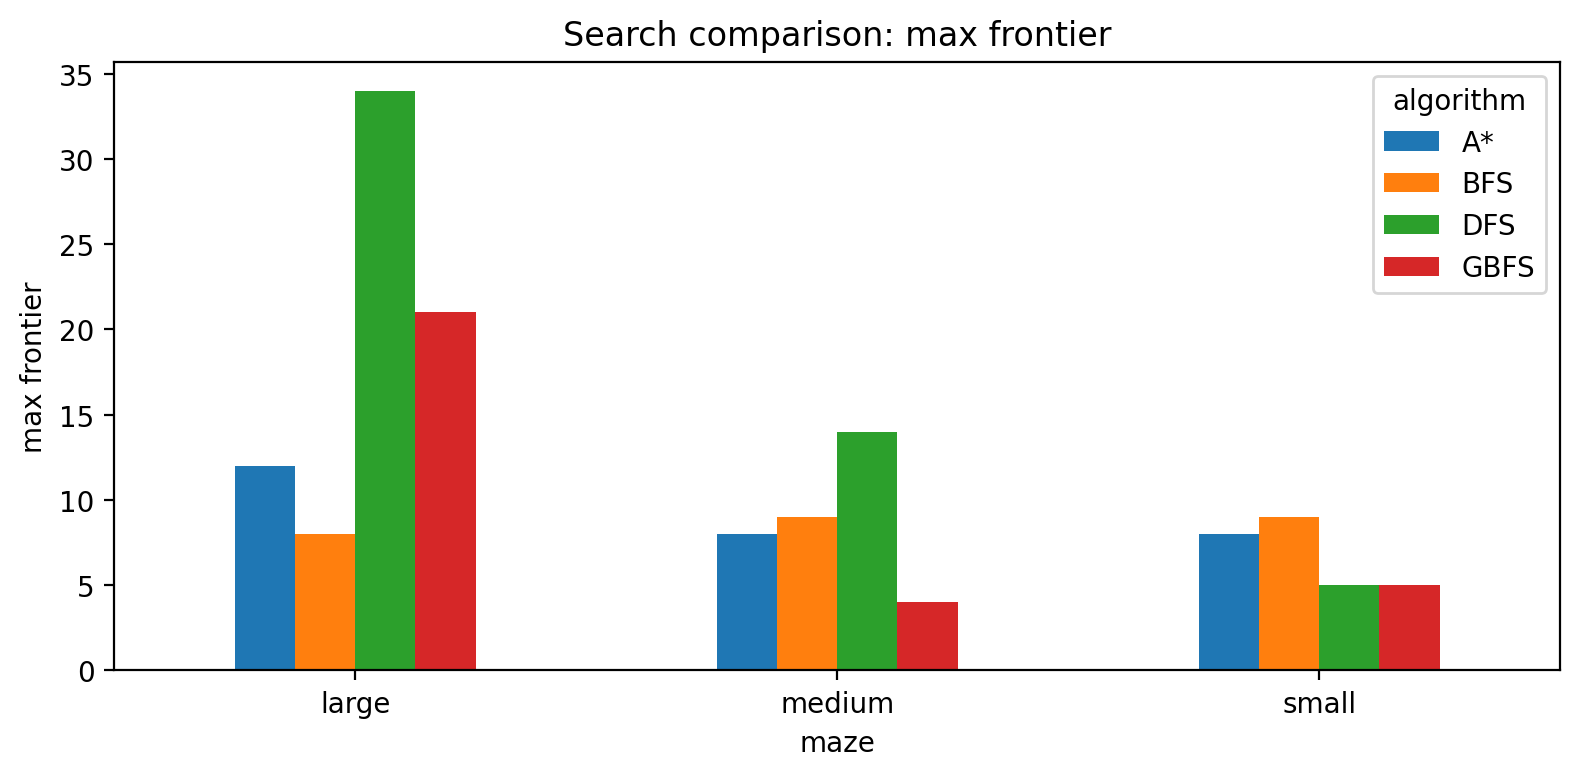

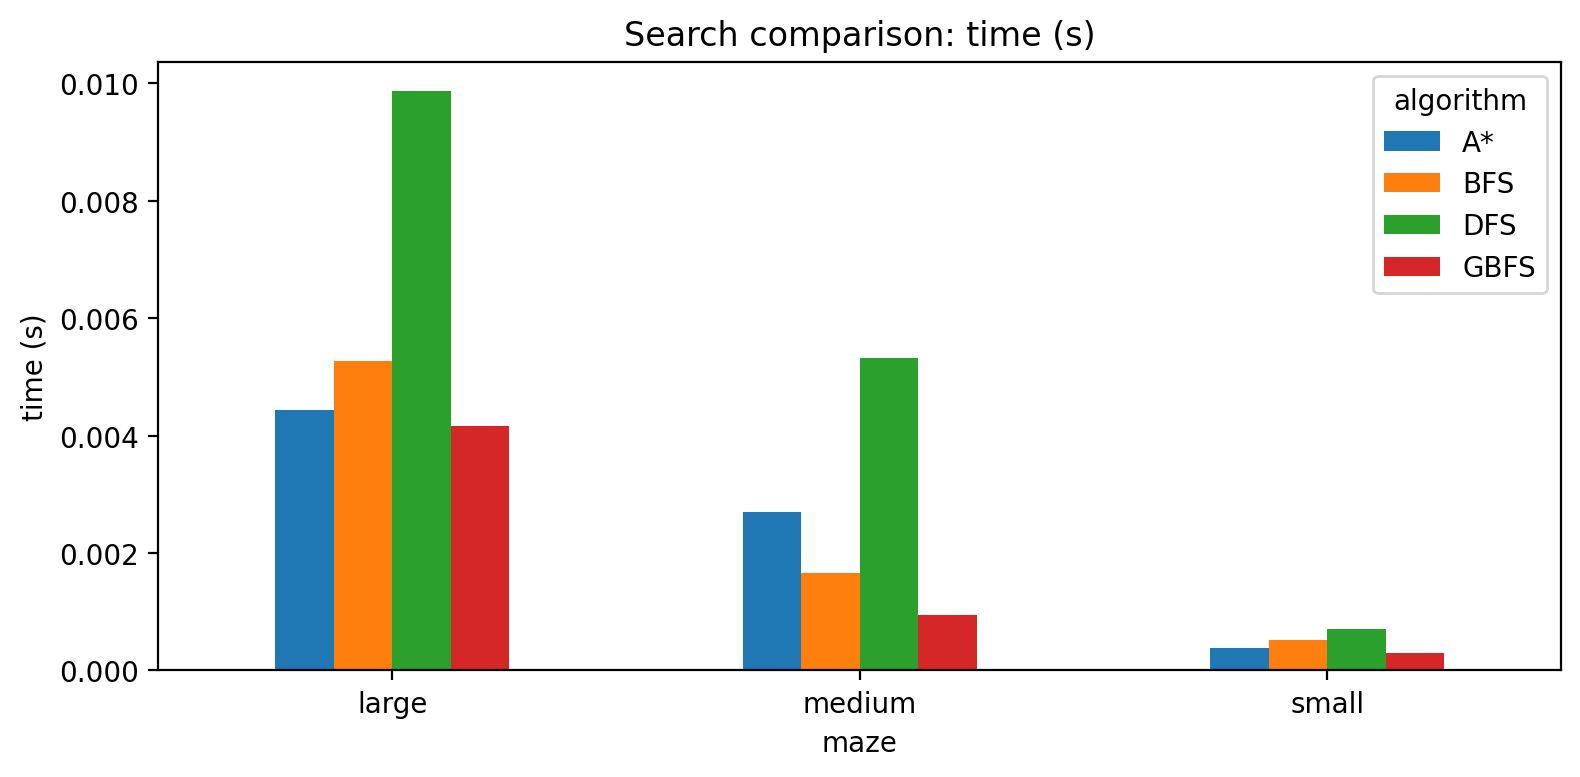

In [15]:
import matplotlib.pyplot as plt

# One chart per metric to keep the comparison readable.
for metric in ["path cost", "nodes expanded", "max frontier", "time (s)"]:
    pivot = results_df.pivot(index="maze", columns="algorithm", values=metric)
    ax = pivot.plot(kind="bar", figsize=(8, 4))
    ax.set_title(f"Search comparison: {metric}")
    ax.set_ylabel(metric)
    ax.set_xlabel("maze")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


Discuss the most important lessons you have learned from implementing the different search strategies. 

### Discussion
BFS là thuật toán tìm kiếm không thông tin có hành vi ổn định nhất trong bài toán này. Vì mỗi bước đều có cùng chi phí, BFS luôn tìm được đường đi ngắn nhất. Tuy nhiên, BFS phải lưu một lượng lớn node trong frontier và reached set, vì vậy có thể sử dụng nhiều bộ nhớ khi kích thước mê cung tăng.

DFS thường sử dụng ít bộ nhớ hơn BFS vì nó ưu tiên đi sâu theo một nhánh và không cần lưu toàn bộ các trạng thái đã khám phá. Tuy nhiên, kết quả của DFS phụ thuộc rất nhiều vào thứ tự sinh các trạng thái con. DFS có thể đi theo một đường rất dài trước khi tìm thấy goal và không đảm bảo tìm được đường ngắn nhất. Kiểm tra chu trình trên đường đi hiện tại giúp ngăn vòng lặp trực tiếp, nhưng cùng một trạng thái vẫn có thể được khám phá lại qua những nhánh khác nhau.

GBFS chỉ sử dụng heuristic \(h(n)\), vì vậy thường hướng nhanh về phía goal và có thể mở rộng ít node hơn. Tuy nhiên, do không xét chi phí đã đi nên đường tìm được không nhất thiết là đường ngắn nhất.

A* kết hợp cả chi phí đã đi \(g(n)\) và chi phí ước lượng còn lại \(h(n)\). Với Manhattan distance trong lưới bốn hướng, A* vẫn đảm bảo tính tối ưu và thường chỉ cần khảo sát một vùng trạng thái nhỏ hơn BFS.

Kết quả số liệu cụ thể như path cost, số node mở rộng, max depth và max frontier phải lấy từ kết quả thực nghiệm khi chạy notebook, vì đặc biệt với DFS, kết quả có thể thay đổi đáng kể tùy theo thứ tự sinh node và cấu trúc của mê cung. PDF yêu cầu thu thập chính các đại lượng này cho từng thuật toán và từng maze.

## Advanced task: IDS and Multiple goals

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### IDS 
Implement IDS (iterative deepening search) using your DFS implementation. Test IDS on the mazes above. You may run into some issues with mazes with open spaces. If you cannot resolve the issues, then report and discuss what causes the problems.

In [16]:
def depth_limited_dfs(maze, start, goal, limit):
    """Depth-limited DFS with path-cycle checking."""
    root = Node(start, None, None, 0)
    frontier = [root]
    while frontier:
        node = frontier.pop()
        if node.pos == tuple(goal):
            return node
        if node.cost >= limit:
            continue
        for action, child_pos in reversed(valid_successors(maze, node.pos)):
            if not _in_current_path(node, child_pos):
                frontier.append(Node(child_pos, node, action, node.cost + 1))
    return None


def ids(maze, start, goal, max_limit=None):
    if max_limit is None:
        max_limit = int(np.sum(maze != "X"))
    for limit in range(max_limit + 1):
        node = depth_limited_dfs(maze, start, goal, limit)
        if node is not None:
            return {"limit": limit, "plan": node_actions(node), "path_cost": node.cost, "node": node}
    return None

# Example:
ids_result = ids(maze, mh.find_pos(maze, "S"), mh.find_pos(maze, "G"))
print(ids_result)


{'limit': 19, 'plan': ['E', 'E', 'S', 'S', 'W', 'S', 'S', 'W', 'W', 'S', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W'], 'path_cost': 19, 'node': <__main__.Node object at 0x000001E20BA53D20>}


IDS hay Iterative Deepening Search thực hiện DFS nhiều lần với giới hạn độ sâu tăng dần: $0,1,2,\ldots$

Ở mỗi lần lặp, thuật toán thực hiện Depth-Limited DFS với giới hạn mới. Nếu goal chưa được tìm thấy thì giới hạn độ sâu được tăng lên và tìm kiếm được thực hiện lại.

IDS kết hợp một số ưu điểm của BFS và DFS. Nó tìm lời giải theo độ sâu tăng dần giống BFS nên có thể tìm được lời giải nông nhất khi chi phí mỗi bước bằng nhau, nhưng vẫn chỉ cần lượng bộ nhớ gần giống DFS.

Tuy nhiên, giống như PDF lưu ý, hiệu quả của IDS phụ thuộc vào cơ chế cycle checking của DFS. Nếu cycle checking không được thiết kế phù hợp, đặc biệt trong các vùng mở của maze, thuật toán có thể gặp vấn đề hoặc lặp lại rất nhiều trạng thái.

### Multiple Goals 
Create a few mazes with multiple goals by adding one or two more goals to the medium size maze. The agent is done when it finds one of the goals.
Solve the maze with your implementations for DFS, BFS, and IDS. Run experiments to show which implementations find the optimal solution and which do not. Discuss why that is the case.

In [21]:
def find_all_goals(maze):
    return [tuple(p) for p in np.argwhere(maze == "G")]


def bfs_multiple_goals(maze, start, goals):
    goals = set(map(tuple, goals))
    root = Node(start, None, None, 0)
    frontier = deque([root])
    reached = {root.pos}
    while frontier:
        node = frontier.popleft()
        if node.pos in goals:
            return {
                "goal": node.pos,
                "plan": node_actions(node),
                "path_cost": node.cost
            }
        for action, child_pos in valid_successors(maze, node.pos):
            if child_pos not in reached:
                reached.add(child_pos)
                frontier.append(Node(child_pos, node, action, node.cost + 1))
    return None

m_maze = load_maze_file("medium_multi_goal_maze.txt")
m_start = mh.find_pos(m_maze, "S")
m_goals = find_all_goals(m_maze)

print("Start:", m_start)
print("Goals:", m_goals)
print("Number of goals:", len(m_goals))

multi_result = bfs_multiple_goals(
    m_maze,
    mh.find_pos(m_maze, "S"),
    find_all_goals(m_maze)
)

print(multi_result)

Start: (np.int64(1), np.int64(34))
Goals: [(np.int64(9), np.int64(31)), (np.int64(15), np.int64(18)), (np.int64(16), np.int64(1))]
Number of goals: 3
{'goal': (np.int64(9), np.int64(31)), 'plan': ['S', 'S', 'W', 'W', 'W', 'W', 'S', 'S', 'E', 'E', 'E', 'E', 'S', 'S', 'W', 'W', 'W', 'W', 'S', 'S', 'E'], 'path_cost': 21}


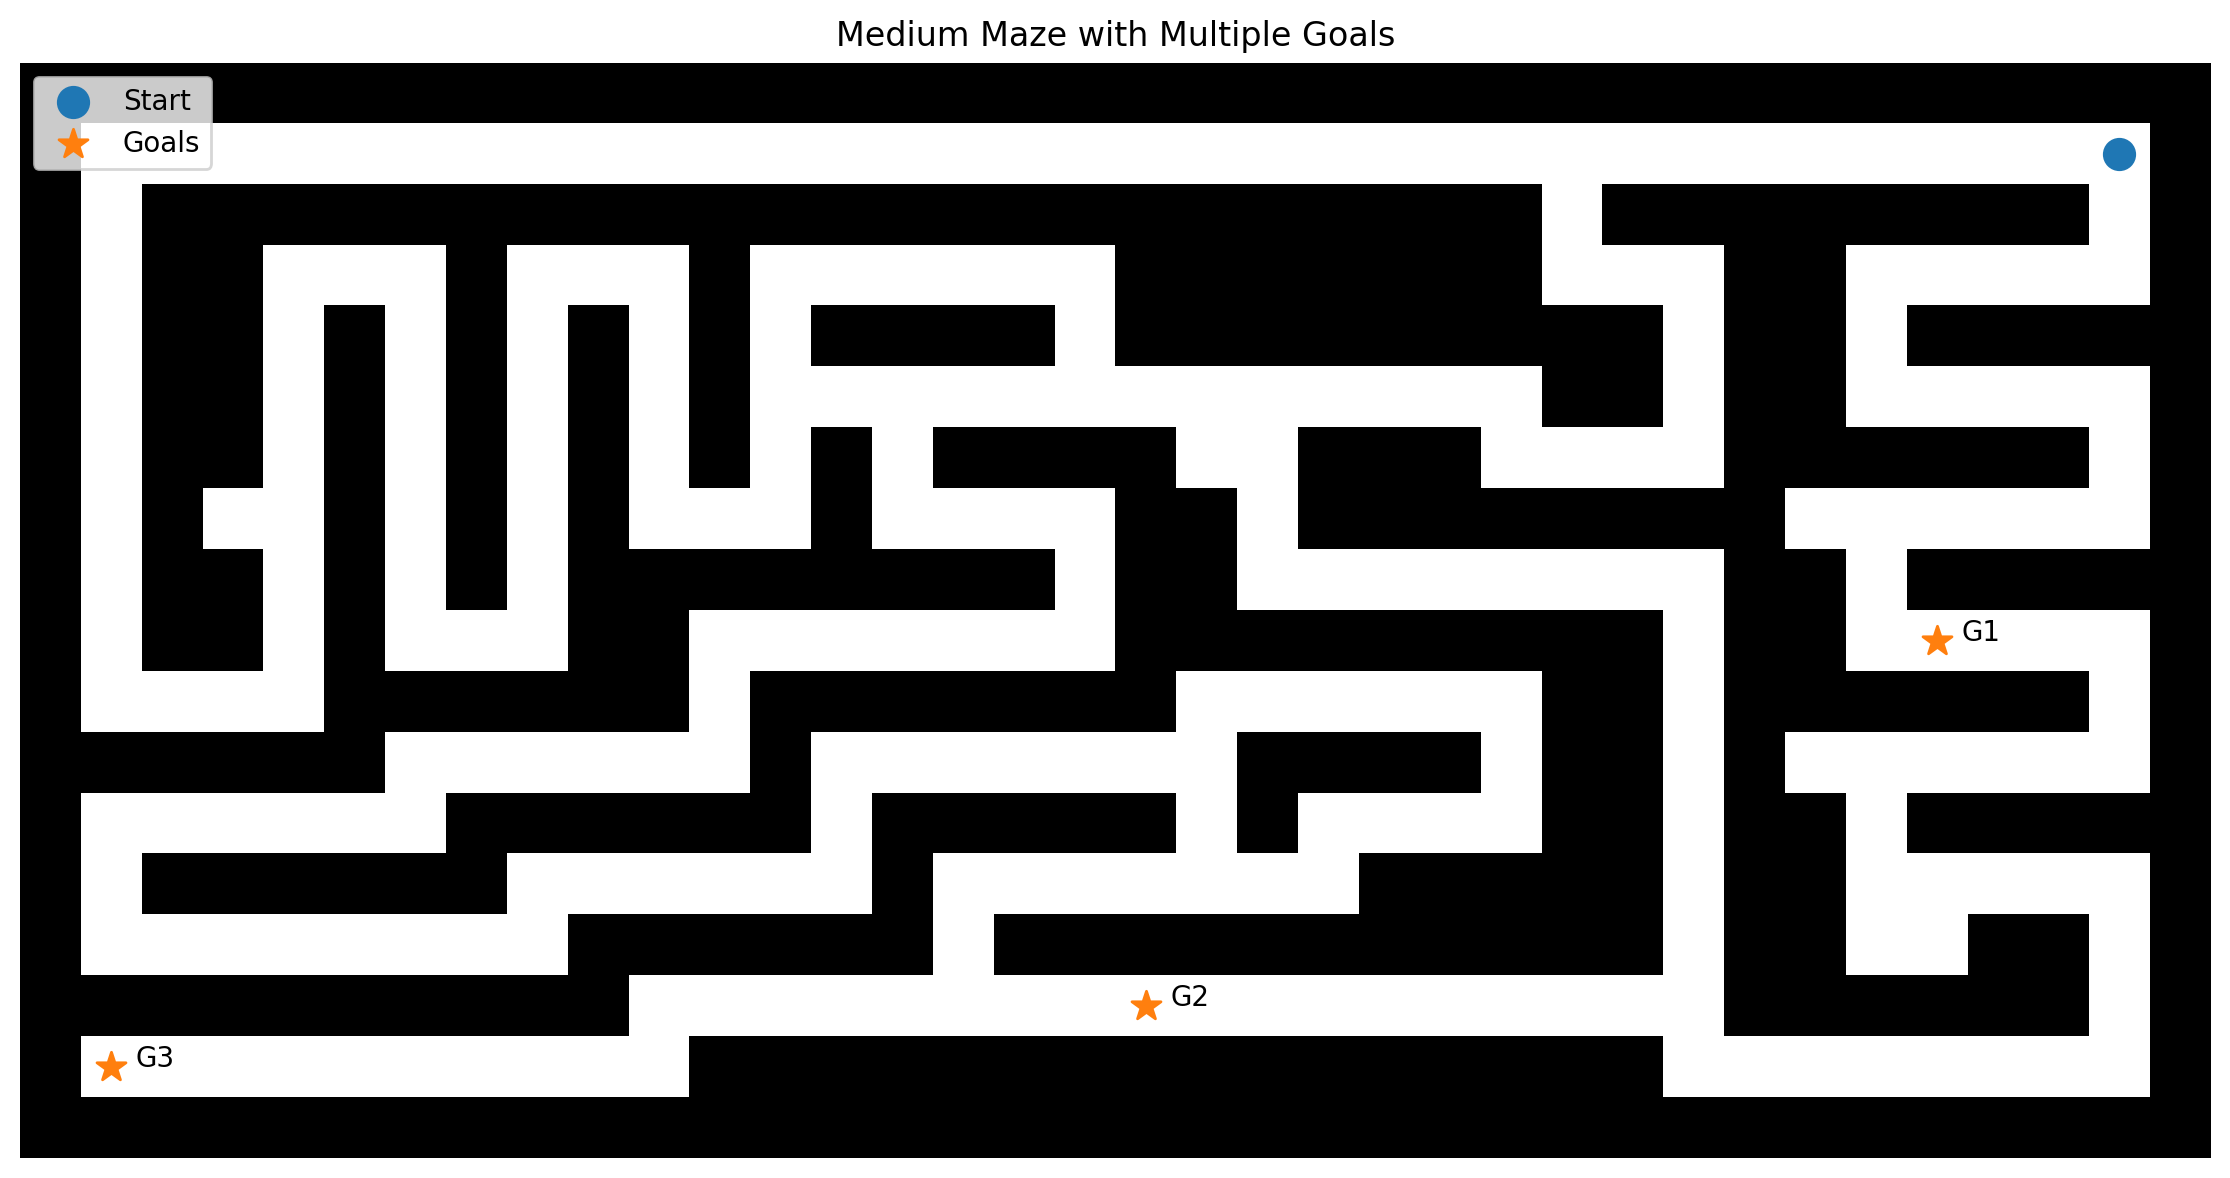

In [22]:
def show_multi_goal_maze(maze, start, goals):
    display_maze = np.where(maze == "X", 0, 1)

    plt.figure(figsize=(12, 6))

    plt.imshow(
        display_maze,
        cmap="gray"
    )

    # Start
    plt.scatter(
        start[1],
        start[0],
        s=120,
        marker="o",
        label="Start"
    )

    # Goals
    goal_cols = [g[1] for g in goals]
    goal_rows = [g[0] for g in goals]

    plt.scatter(
        goal_cols,
        goal_rows,
        s=120,
        marker="*",
        label="Goals"
    )

    # Ghi nhãn từng goal
    for i, g in enumerate(goals, start=1):
        plt.text(
            g[1] + 0.4,
            g[0],
            f"G{i}",
            fontsize=10
        )

    plt.title(
        "Medium Maze with Multiple Goals"
    )

    plt.legend()
    plt.axis("off")
    plt.tight_layout()
    plt.show()

show_multi_goal_maze(
    m_maze,
    m_start,
    m_goals
)

Tác tử hoàn thành nhiệm vụ ngay khi đến được một trong các goal.

BFS vẫn tìm goal có độ sâu nhỏ nhất vì nó duyệt theo từng mức độ sâu. Khi mọi hành động có cùng cost, goal đầu tiên được BFS tìm thấy sẽ tương ứng với đường đi ngắn nhất.

DFS không đảm bảo tìm goal gần nhất vì nó đi sâu theo một nhánh trước. Do đó, nó có thể tìm thấy một goal ở rất xa trong khi tồn tại một goal khác gần trạng thái bắt đầu hơn.

GBFS ưu tiên goal hoặc vùng có heuristic nhỏ nên thường hướng về goal có vẻ gần nhất theo heuristic, nhưng không đảm bảo đường thực tế tối ưu.

A* sử dụng cả \(g(n)\) và \(h(n)\), do đó nếu heuristic phù hợp thì có thể tìm được đường tối ưu đến goal có tổng chi phí nhỏ nhất.

## More Advanced Problems to Think About (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment. 

### Intersection as States
Instead of defining each square as a state, use only intersections as states. Now the storage requirement is reduced, but the path length between two intersections can be different. If we use total path length measured as the number of squares as path cost, how can we make sure that BFS and iterative deepening search is optimal? Change the code to do so.

In [18]:
# Your code/answer goes here

### Weighted A* search
Modify your A* search to add weights (see text book) and explore how different weights influence the result.

In [19]:
# Your code/answer goes here

### Unknown Maze
What happens if the agent does not know the layout of the maze in advance? This means that the agent faces an unknown environment, where it does not know the transition function. How does the environment look then (PEAS description)? How would you implement a rational agent to solve the maze? What if the agent still has a GPS device to tell the distance to the goal?

In [20]:
# Your code/answer goes here